<a href="https://colab.research.google.com/github/RajolKumar2003/Computer-Log-Anomaly-Detection/blob/dataset-code/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NETWORK TRAFFIC ANOMALY DETECTION - EXPLORATORY DATA ANALYSIS
## Dataset:
https://www.kaggle.com/datasets/ziya07/network-traffic-anomaly-detection-dataset

### Objective:
Perform complete Exploratory Data Analysis (EDA) on the
Network Traffic Anomaly Detection dataset.
This script covers:
1. Data Loading
2. Dataset Overview
3. Missing Value Analysis
4. Statistical Summary
5. Class Distribution
6. Numerical Feature Analysis
7. Correlation Analysis
8. Outlier Detection
9. Feature Relationship Visualization
10. Insights Generation
------------------------------------------------------------------------------------

### 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### 2. LOAD DATASET

In [ ]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Change this path to where you saved the file in your Drive
file_path = '/content/drive/MyDrive/embedded_system_network_security_dataset.csv'

# 3. Load dataset
df = pd.read_csv(file_path)

Mounted at /content/drive


### 3. BASIC DATASET INFORMATION

In [ ]:
print("\n================ DATASET OVERVIEW ================\n")
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)



================ DATASET OVERVIEW ================

First 5 Rows:
   packet_size  inter_arrival_time  src_port  dst_port  packet_count_5s  \
0     0.405154            0.620362     62569       443         0.857143   
1     0.527559            0.741288     59382       443         0.785714   
2     0.226199            0.485116     65484        80         0.285714   
3     0.573372            0.450965     51707        53         0.142857   
4     0.651396            0.888740     26915        53         0.714286   

   mean_packet_size  spectral_entropy  frequency_band_energy  label  \
0               0.0          0.834066               0.534891    0.0   
1               0.0          0.147196               0.990757    0.0   
2               0.0          0.855192               0.031781    0.0   
3               0.0          0.153220               0.169958    0.0   
4               0.0          0.923916               0.552053    0.0   

   protocol_type_TCP  protocol_type_UDP  src_ip_192.168

### Ignore Boolean Culumns

In [ ]:
df = df = df.select_dtypes(exclude='bool')
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0


### 4. MISSING VALUE ANALYSIS


================ MISSING VALUES ================

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
dtype: int64


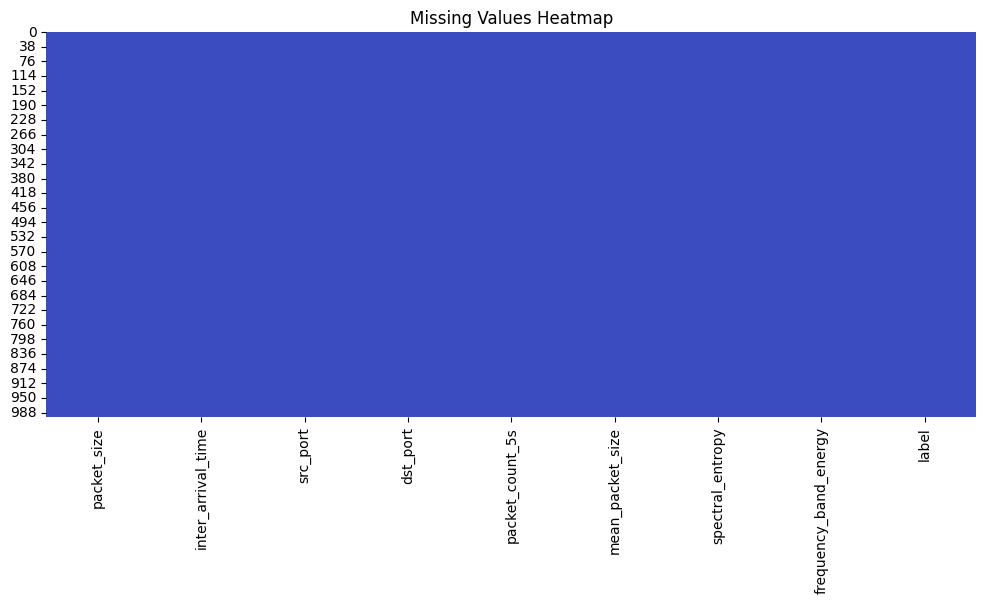

In [ ]:
print("\n================ MISSING VALUES ================\n")

missing_values = df.isnull().sum()

print(missing_values)

# Visualize missing values
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

### 5. DUPLICATE RECORDS

In [ ]:
print("\n================ DUPLICATE RECORDS ================\n")

duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicates}")


================ DUPLICATE RECORDS ================

Number of Duplicate Rows: 0


### 6. STATISTICAL SUMMARY

In [ ]:
print("\n================ STATISTICAL SUMMARY ================\n")

print(df.describe())


================ STATISTICAL SUMMARY ================

       packet_size  inter_arrival_time      src_port     dst_port  \
count  1000.000000         1000.000000   1000.000000  1000.000000   
mean      0.502446            0.512259  32024.617000   199.769000   
std       0.289606            0.281130  18520.890349   180.078488   
min       0.000000            0.000000   1038.000000    53.000000   
25%       0.256263            0.275909  16245.250000    53.000000   
50%       0.499642            0.515971  31883.000000    80.000000   
75%       0.741410            0.746523  47746.250000   443.000000   
max       1.000000            1.000000  65484.000000   443.000000   

       packet_count_5s  mean_packet_size  spectral_entropy  \
count      1000.000000            1000.0       1000.000000   
mean          0.506857               0.0          0.495222   
std           0.303271               0.0          0.292927   
min           0.000000               0.0          0.000000   
25%         

### 7. TARGET VARIABLE ANALYSIS
Target column name = 'label'

0 = Normal Traffic

1 = Anomalous Traffic



================ TARGET VARIABLE DISTRIBUTION ================

label
0.0    900
1.0    100
Name: count, dtype: int64


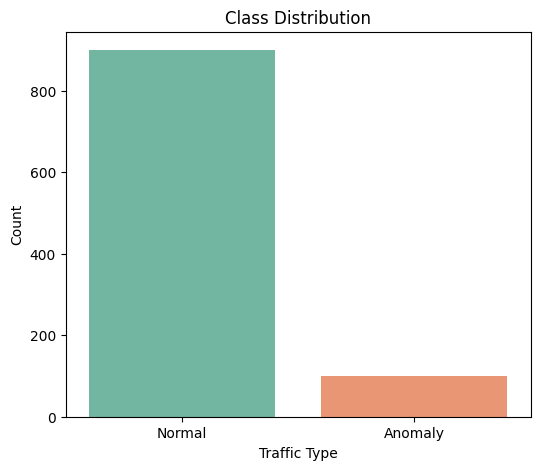

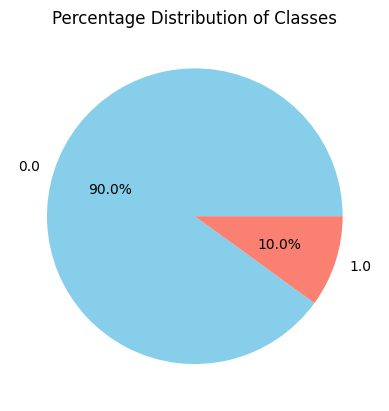

In [ ]:
target_column = "label"

print("\n================ TARGET VARIABLE DISTRIBUTION ================\n")

print(df[target_column].value_counts())

# Countplot
plt.figure(figsize=(6, 5))
sns.countplot(x=df[target_column], palette="Set2")

plt.title("Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Anomaly"])

plt.show()

# Pie Chart
df[target_column].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon']
)

plt.title("Percentage Distribution of Classes")
plt.ylabel("")
plt.show()


### 8. NUMERICAL FEATURE ANALYSIS


================ NUMERICAL FEATURES ================

['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy']


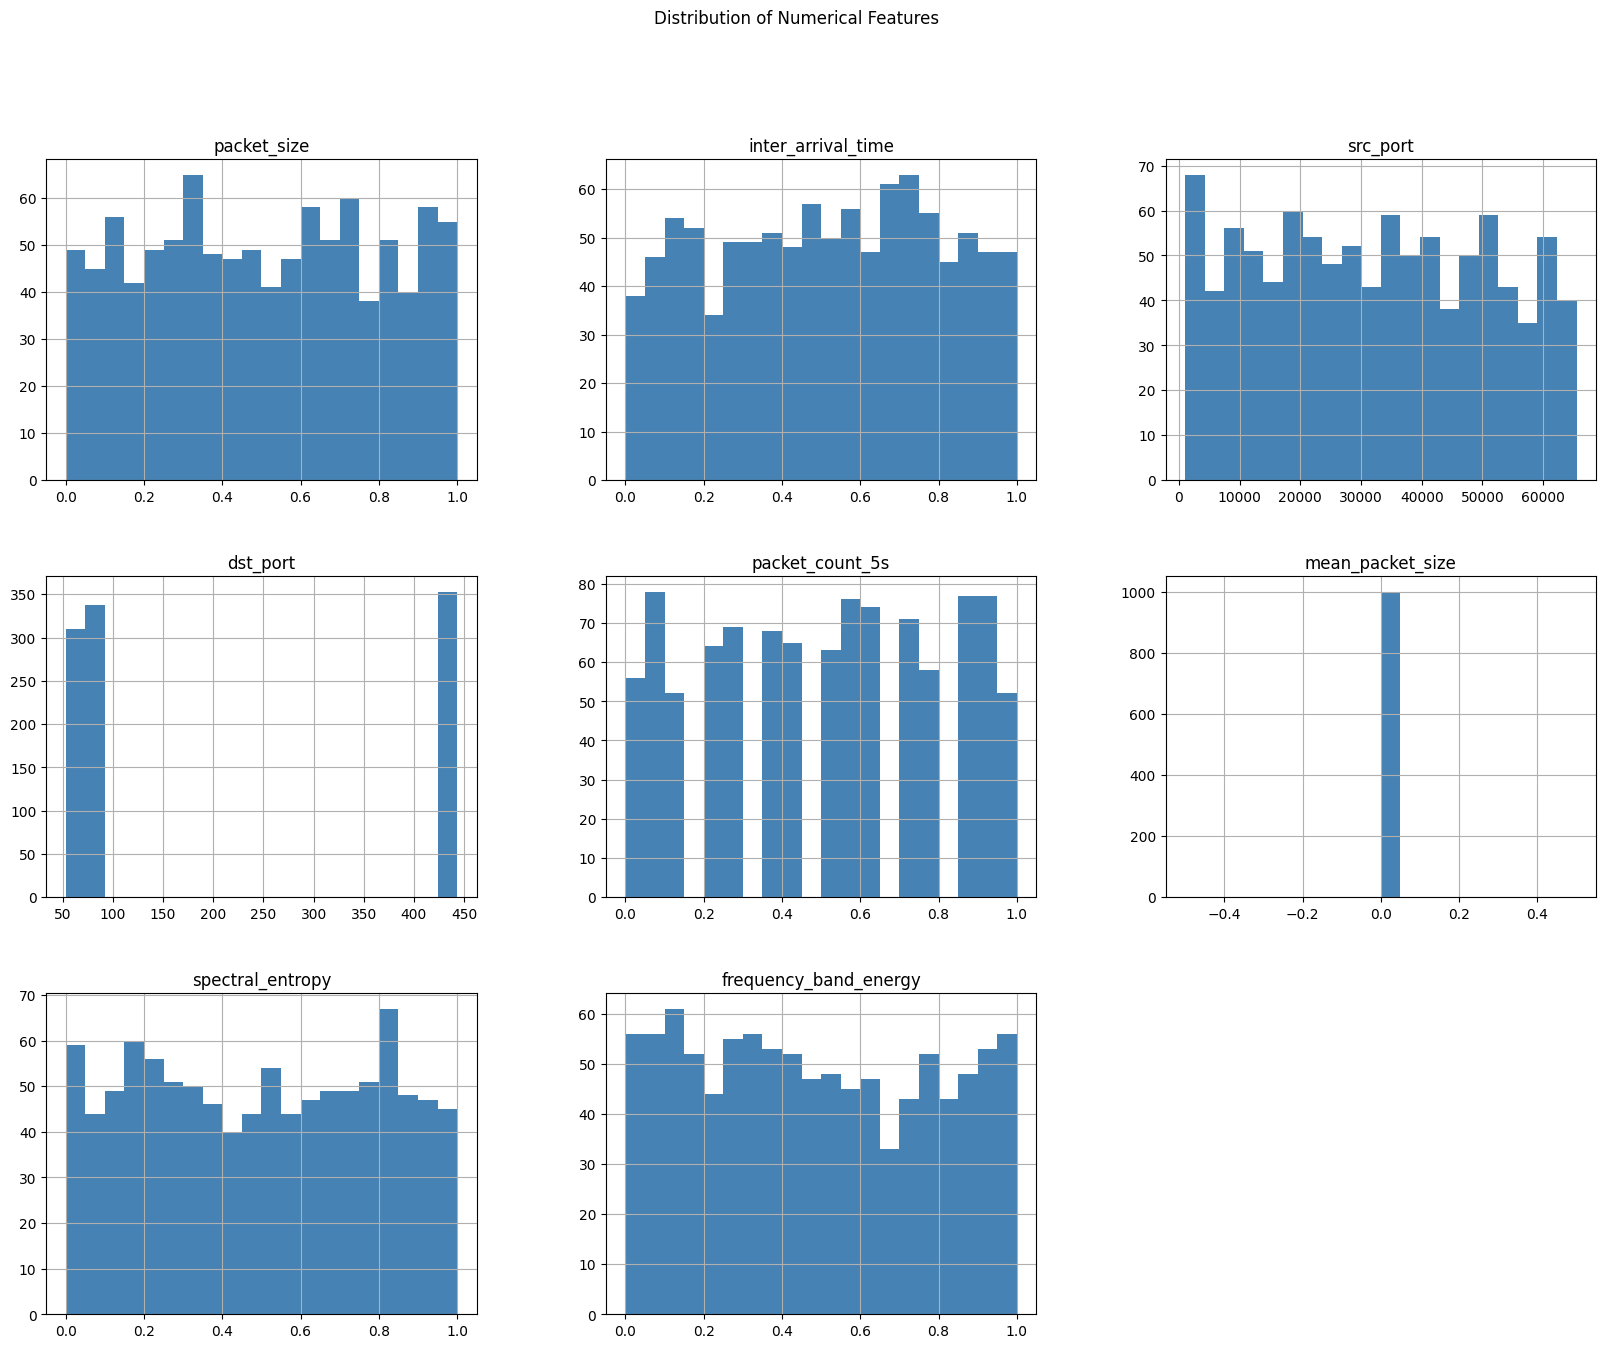

In [ ]:
print("\n================ NUMERICAL FEATURES ================\n")

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target column from numerical features
if target_column in numerical_cols:
    numerical_cols.remove(target_column)

print(numerical_cols)

# Histograms
df[numerical_cols].hist(
    bins=20,
    figsize=(20, 15),
    color='steelblue'
)

plt.suptitle("Distribution of Numerical Features")
plt.show()

### 9. BOXPLOTS FOR OUTLIER DETECTION


================ OUTLIER ANALYSIS ================



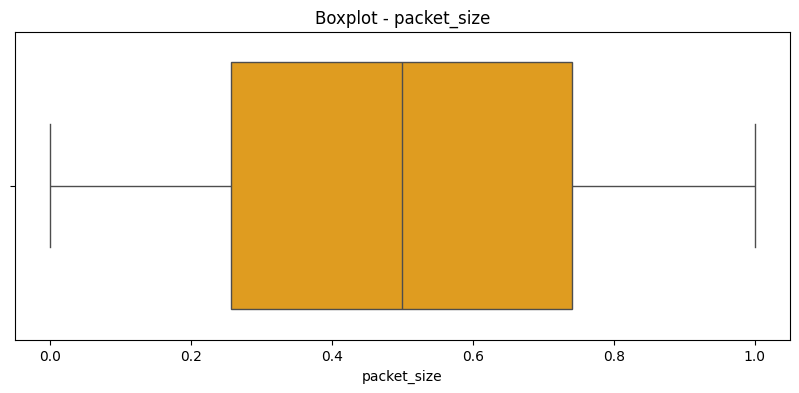

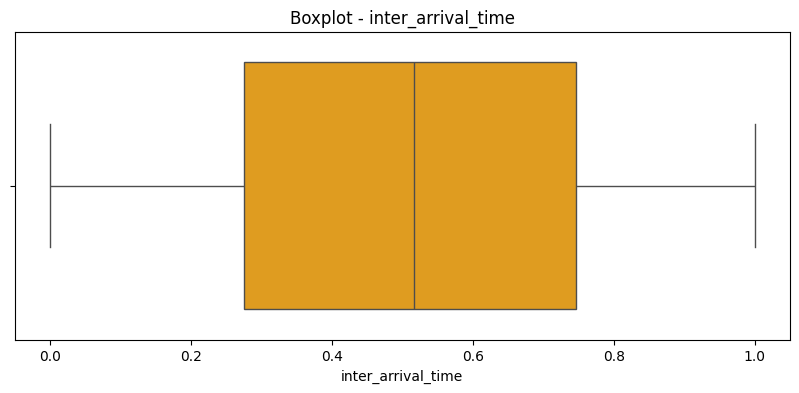

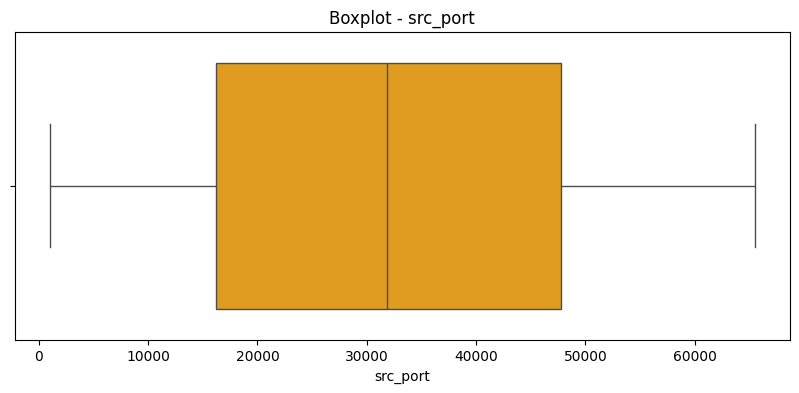

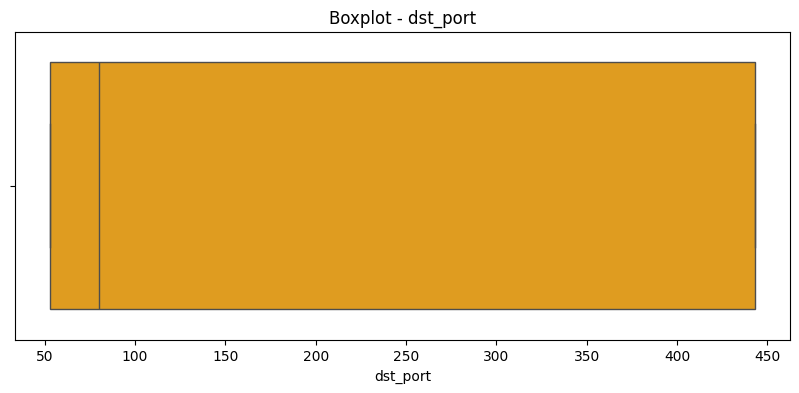

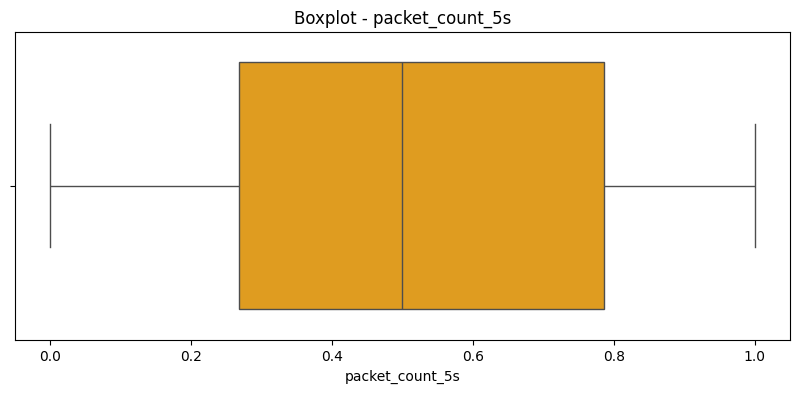

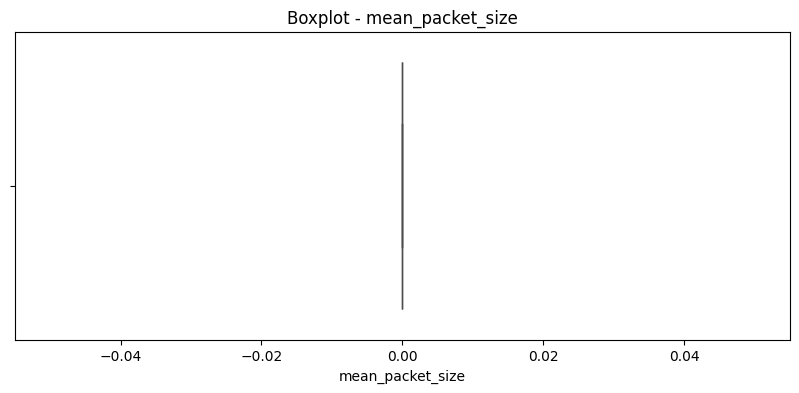

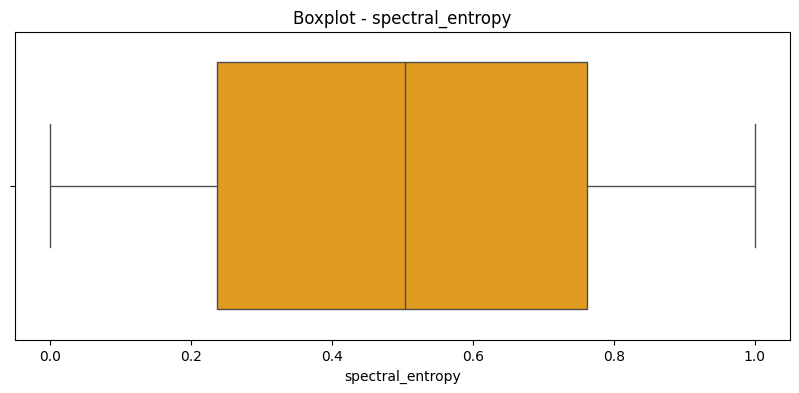

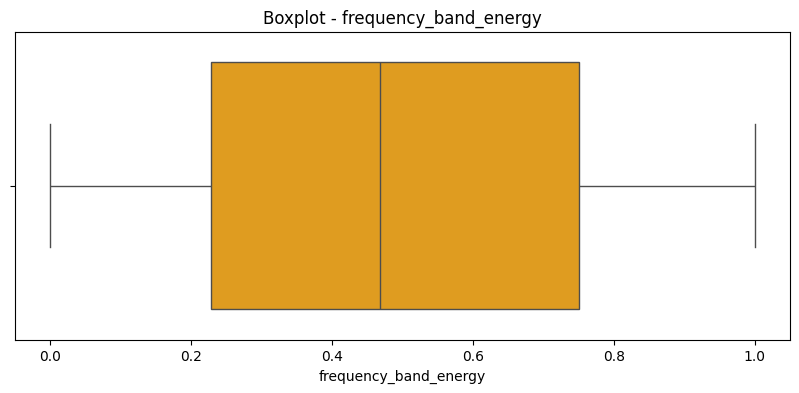

In [ ]:
print("\n================ OUTLIER ANALYSIS ================\n")

for col in numerical_cols:

    plt.figure(figsize=(10, 4))

    sns.boxplot(x=df[col], color='orange')

    plt.title(f"Boxplot - {col}")

    plt.show()

### 10. CORRELATION ANALYSIS


================ CORRELATION ANALYSIS ================



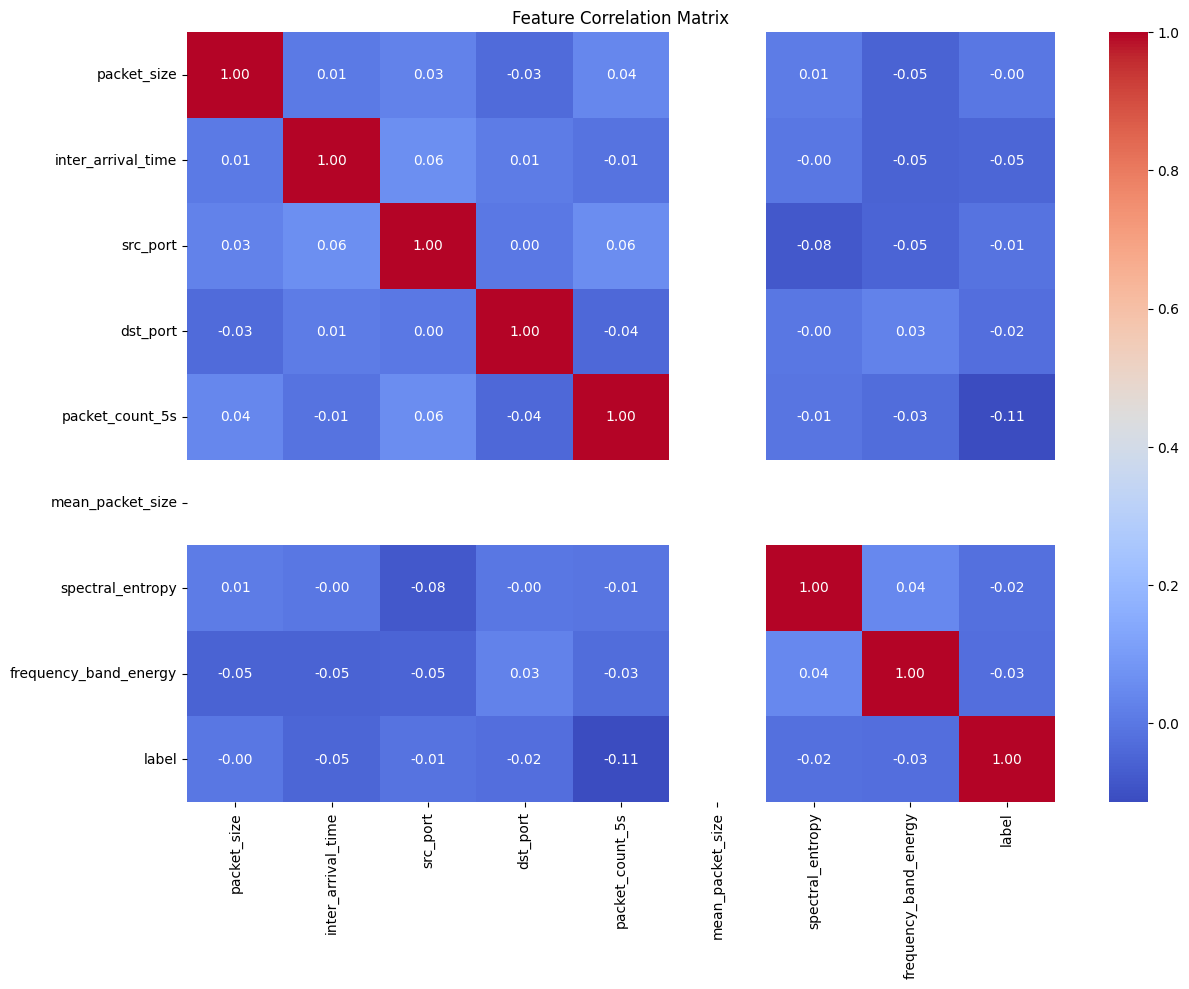

In [ ]:
print("\n================ CORRELATION ANALYSIS ================\n")

correlation_matrix = df[numerical_cols + [target_column]].corr()

# Heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()


### 10. FEATURE RELATIONSHIP WITH TARGET


================ FEATURE VS TARGET ANALYSIS ================



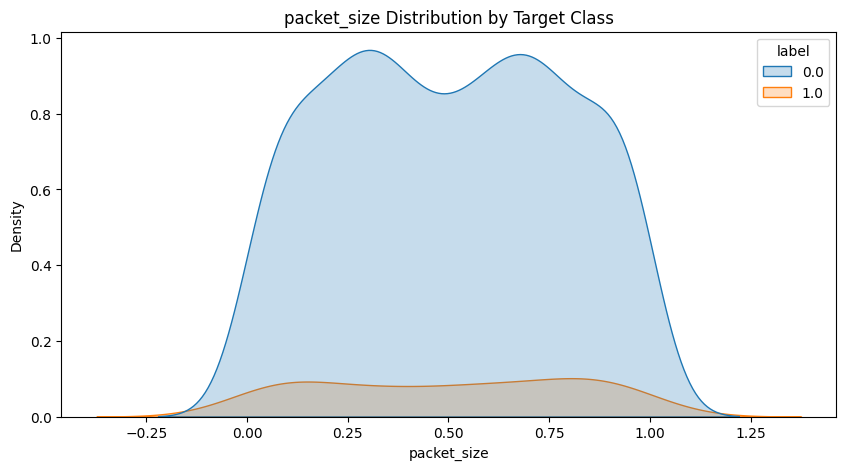

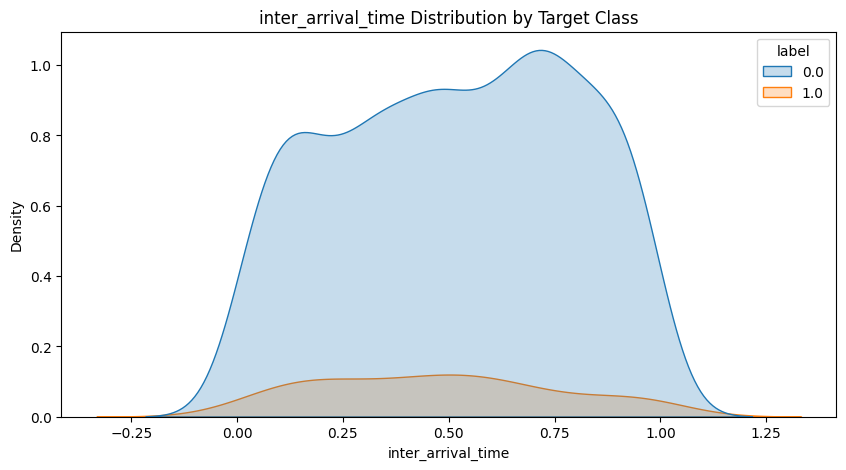

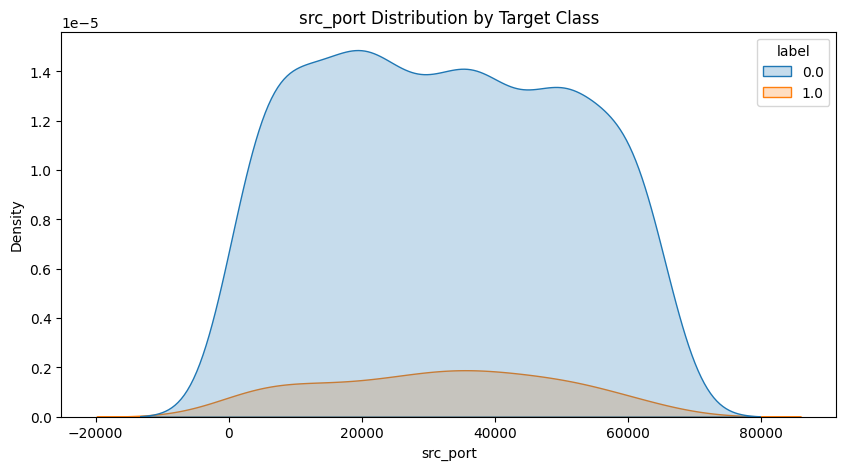

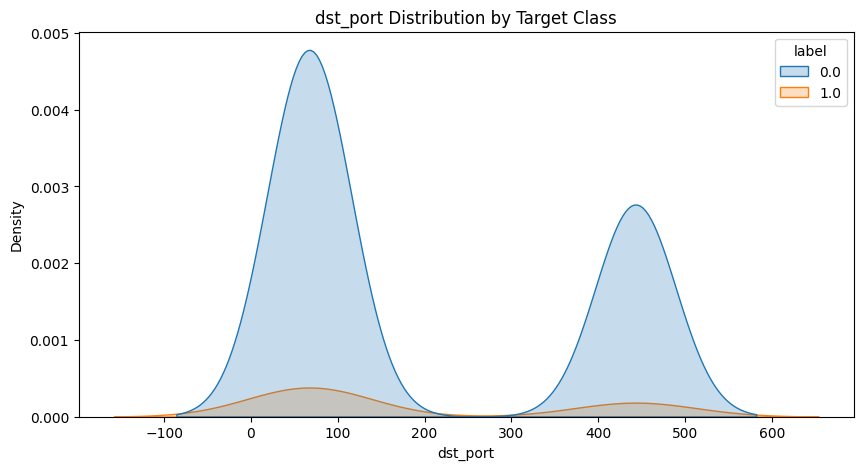

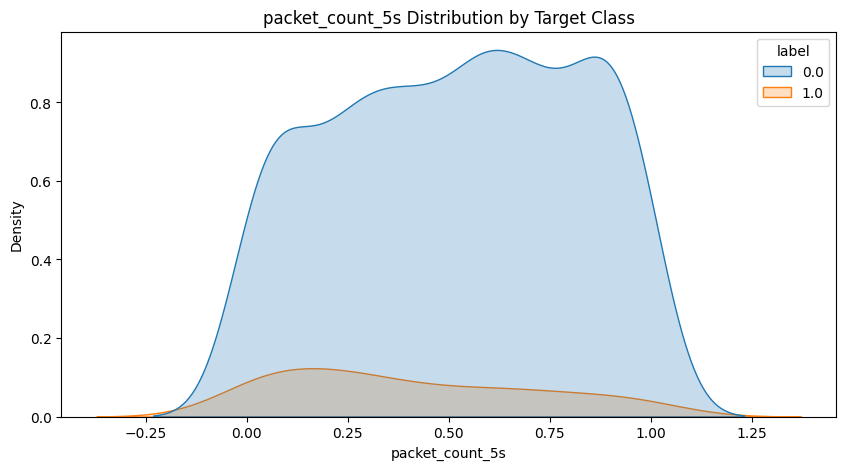

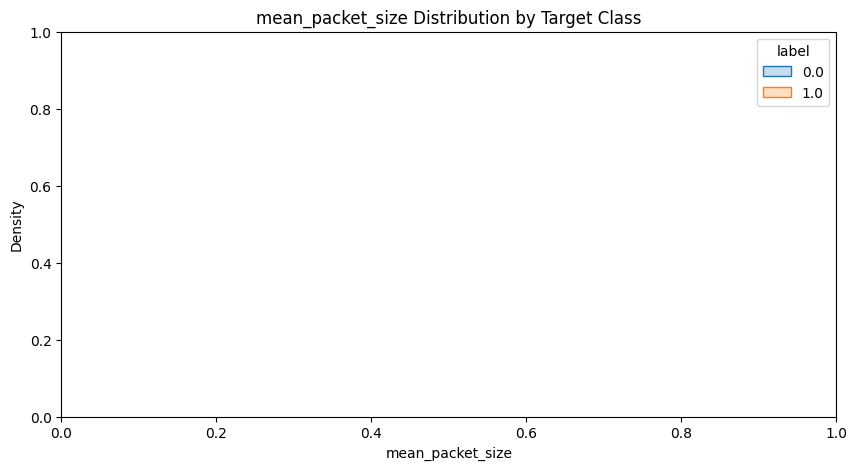

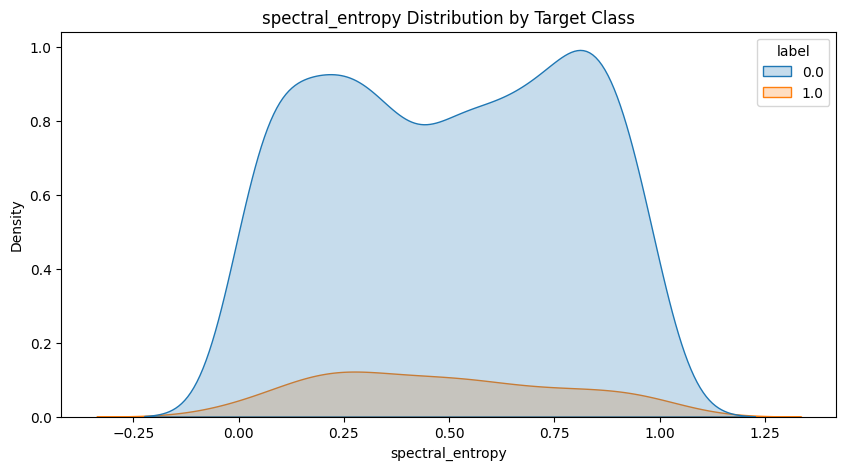

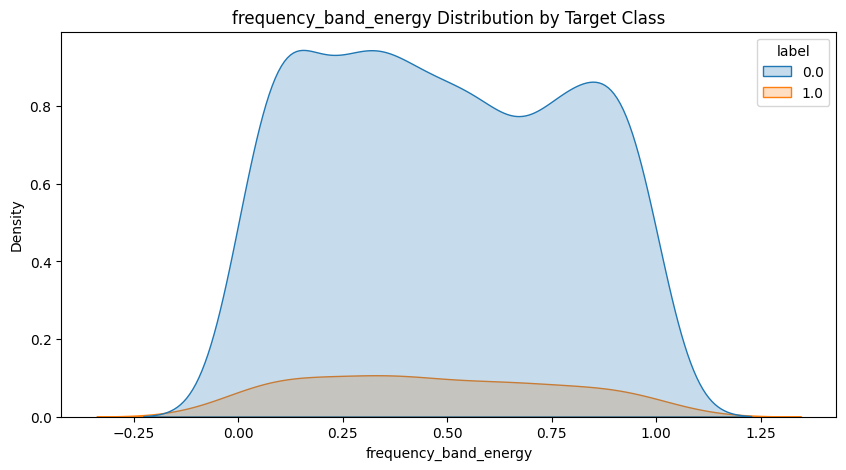

In [ ]:
print("\n================ FEATURE VS TARGET ANALYSIS ================\n")

for col in numerical_cols[:10]:

    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        data=df,
        x=col,
        hue=target_column,
        fill=True
    )

    plt.title(f"{col} Distribution by Target Class")

    plt.show()

### 12. PAIRPLOT ANALYSIS
Pairplot helps identify:
- Class separation
- Correlations
- Clusters

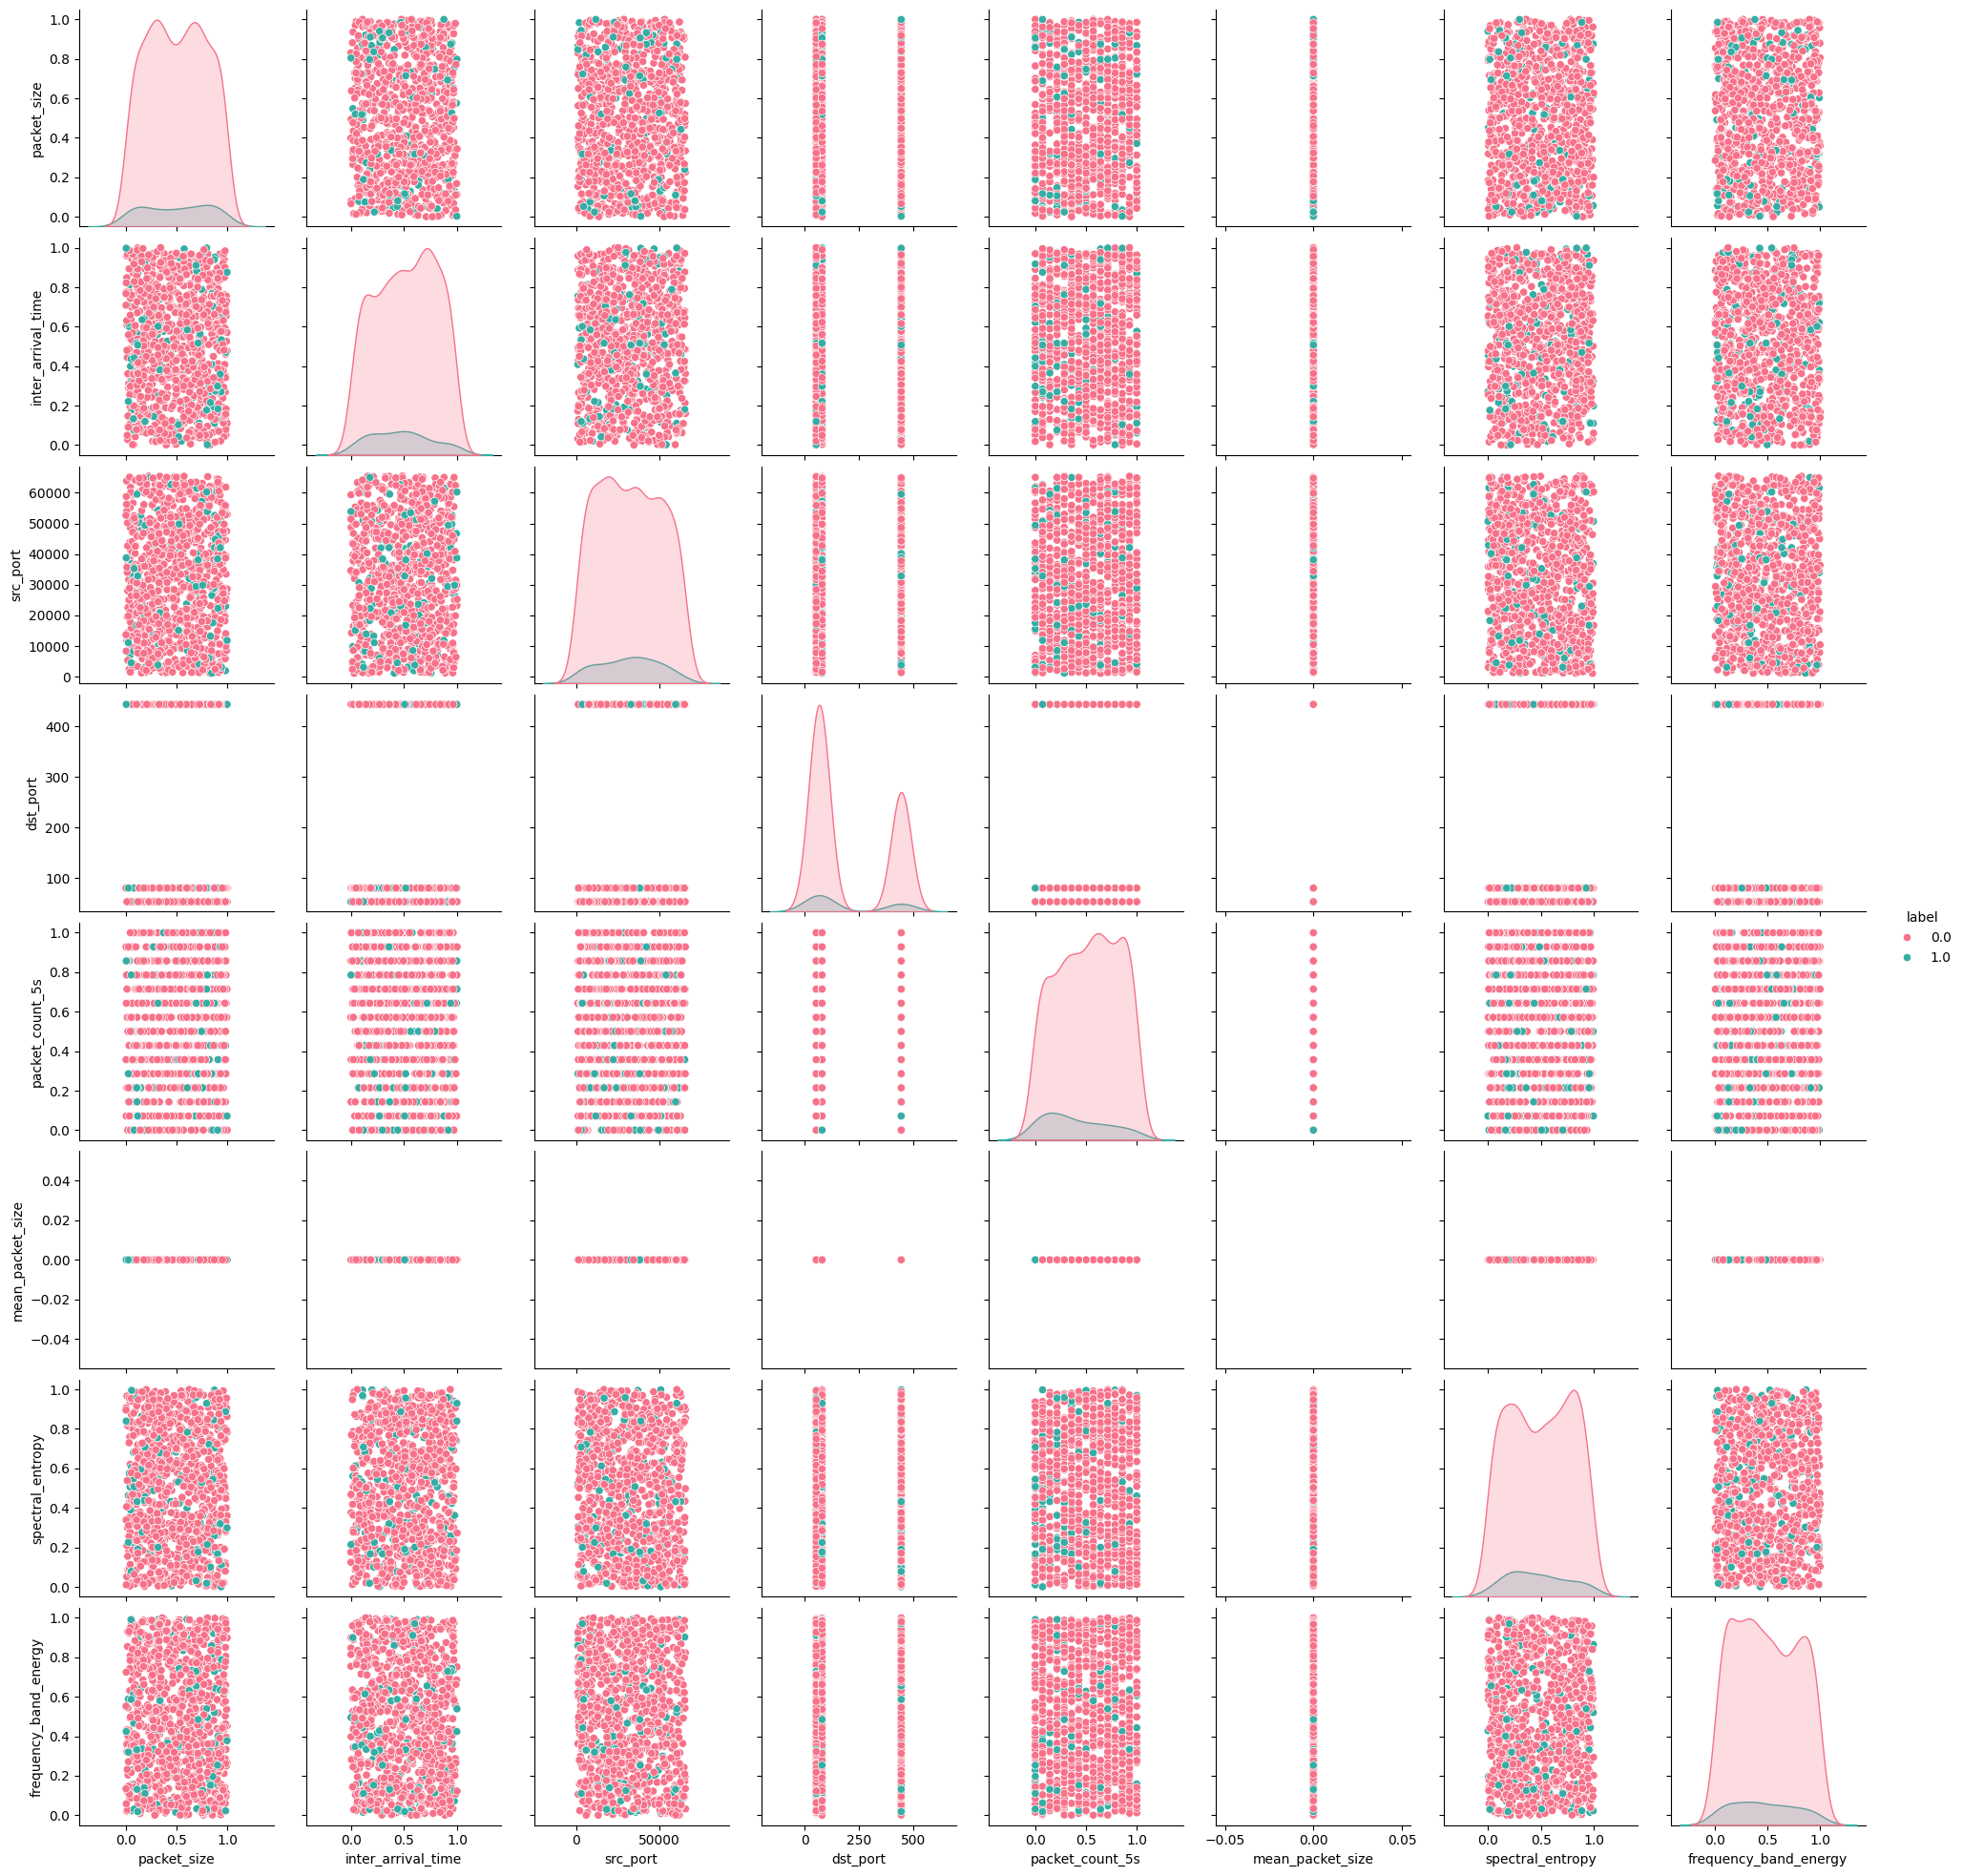

In [ ]:
selected_cols = numerical_cols[:10] + [target_column]

sns.pairplot(
    df[selected_cols],
    hue=target_column,
    palette="husl"
)

plt.show()

### 14. ANOMALY TRAFFIC ANALYSIS
Analyze how anomalies differ from normal traffic.

In [ ]:
anomaly_df = df[df[target_column] == 1]
normal_df = df[df[target_column] == 0]

print("\nAverage Feature Values for Anomalous Traffic:\n")
print(anomaly_df[numerical_cols].mean())

print("\nAverage Feature Values for Normal Traffic:\n")
print(normal_df[numerical_cols].mean())


Average Feature Values for Anomalous Traffic:

packet_size                  0.501016
inter_arrival_time           0.473604
src_port                 31484.770000
dst_port                   187.520000
packet_count_5s              0.403571
mean_packet_size             0.000000
spectral_entropy             0.478122
frequency_band_energy        0.463242
dtype: float64

Average Feature Values for Normal Traffic:

packet_size                  0.502605
inter_arrival_time           0.516554
src_port                 32084.600000
dst_port                   201.130000
packet_count_5s              0.518333
mean_packet_size             0.000000
spectral_entropy             0.497122
frequency_band_energy        0.488141
dtype: float64


### **Final Insights from EDA**




1.  **Data Size**: We looked at 1000 records, each with 9 key measurements about network traffic.
2.  **Unbalanced Data**: Most of our data (90%) is 'normal' traffic, while only a small part (10%) is 'anomalous' (suspicious). This means our detection system needs to be very good at spotting the rare anomalies.
3.  **Key Differences**: Some traffic characteristics, like the source and destination ports, how quickly packets arrive, and how many packets are seen in a short time, look different for normal vs. anomalous traffic. These are important clues for finding anomalies.
4.  **No Missing Data**: We don't have any gaps in our data, so all information is complete.
5.  **Some Outliers**: There are a few data points that are very different from the rest (outliers). We should be careful with these as they might be real anomalies or just unusual but normal events.
6.  **'Mean Packet Size' is Empty**: One measurement called 'mean_packet_size' was always zero, so it's not useful for our analysis.
7.  **Feature Relationships**: Some measurements move together (they are correlated). For example, if one goes up, the other might too. Understanding these links helps us see patterns.

## Preparing Data for Machine Learning

Based on our EDA, we identified a few key areas to address before training a classification model:

1.  **Feature Scaling**: Ensuring all numerical features contribute equally to the model by bringing them to a similar scale.
2.  **Handling Class Imbalance**: Our dataset has a significant imbalance between normal and anomalous traffic. We'll use techniques like oversampling to address this, preventing the model from being biased towards the majority class.
3.  **Data Splitting**: Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
# Import necessary libraries for scaling and splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Identify numerical features to scale (excluding 'label' and 'mean_packet_size' as it's constant zero)
numerical_features_to_scale = [col for col in df.columns if col not in ['label', 'mean_packet_size']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df_scaled = df.copy()
df_scaled[numerical_features_to_scale] = scaler.fit_transform(df_scaled[numerical_features_to_scale])

print("Scaled DataFrame head:")
print(df_scaled.head())

Scaled DataFrame head:
   packet_size  inter_arrival_time  src_port  dst_port  packet_count_5s  \
0    -0.336115            0.384724  1.650011  1.351370         1.155602   
1     0.086758            0.815080  1.477849  1.351370         0.919957   
2    -0.954350           -0.096598  1.807479 -0.665426        -0.729556   
3     0.245026           -0.218135  1.063244 -0.815436        -1.200846   
4     0.514577            1.339842 -0.276022 -0.815436         0.684312   

   mean_packet_size  spectral_entropy  frequency_band_energy  label  
0               0.0          1.157333               0.166460    0.0  
1               0.0         -1.188696               1.707564    0.0  
2               0.0          1.229489              -1.534356    0.0  
3               0.0         -1.168120              -1.067234    0.0  
4               0.0          1.464215               0.224480    0.0  


### 2. Handling Class Imbalance

As observed in our EDA, the dataset is imbalanced (90% normal, 10% anomalous). This can lead to a model that performs well on the majority class but poorly on the minority (anomaly) class. We will use a technique called **SMOTE (Synthetic Minority Over-sampling Technique)** to create synthetic samples of the minority class, balancing the dataset.

In [ ]:
# Install imblearn if not already installed
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = df_scaled.drop('label', axis=1)
y = df_scaled['label']

print(f"Original dataset shape: {X.shape}, labels: {y.value_counts()}")

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled dataset shape: {X_resampled.shape}, labels: {y_resampled.value_counts()}")

Original dataset shape: (1000, 8), labels: label
0.0    900
1.0    100
Name: count, dtype: int64
Resampled dataset shape: (1800, 8), labels: label
0.0    900
1.0    900
Name: count, dtype: int64


### 3. Data Splitting

Splitting the data into training and testing sets is crucial to evaluate the model's performance on unseen data. The training set is used to train the model, and the test set is used to assess how well the model generalizes to new data.

In [ ]:
# Split the resampled data into training and testing sets
# We'll use a 80/20 split for training and testing

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"y_train class distribution:\n{y_train.value_counts()}")
print(f"y_test class distribution:\n{y_test.value_counts()}")

X_train shape: (1440, 8)
X_test shape: (360, 8)
y_train shape: (1440,)
y_test shape: (360,)
y_train class distribution:
label
0.0    720
1.0    720
Name: count, dtype: int64
y_test class distribution:
label
1.0    180
0.0    180
Name: count, dtype: int64


## 4. Train and Evaluate Classification Models

Since data is prepared, We train and evaluate a few standard classification models to detect anomalies. We will use Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.

### 4.1. Logistic Regression

Training the Logistic Regression model...
Training complete.

======== Logistic Regression Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.61      0.66      0.63       180
         1.0       0.63      0.59      0.61       180

    accuracy                           0.62       360
   macro avg       0.62      0.62      0.62       360
weighted avg       0.62      0.62      0.62       360


Confusion Matrix:
[[118  62]
 [ 74 106]]


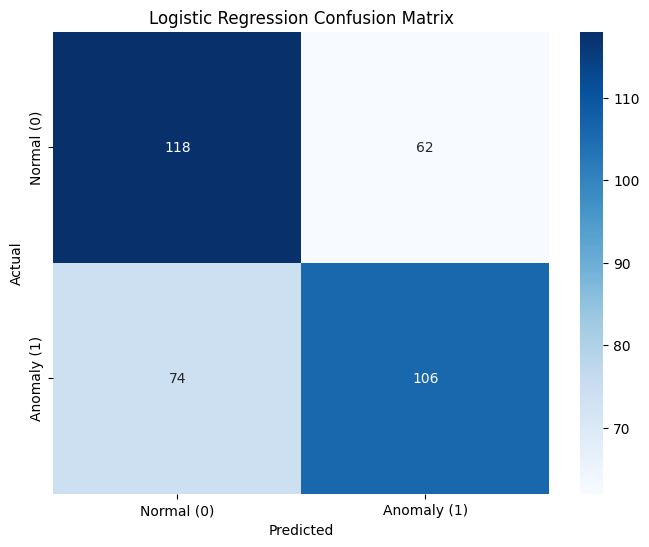


Accuracy: 0.6222


In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and binary classification

# Train the model
print("Training the Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

print("\n======== Logistic Regression Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nAccuracy: {accuracy_lr:.4f}")

### 4.2. Decision Tree Classifier

Training the Decision Tree Classifier model...
Training complete.

======== Decision Tree Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       180
         1.0       0.84      0.83      0.84       180

    accuracy                           0.84       360
   macro avg       0.84      0.84      0.84       360
weighted avg       0.84      0.84      0.84       360


Confusion Matrix:
[[152  28]
 [ 30 150]]


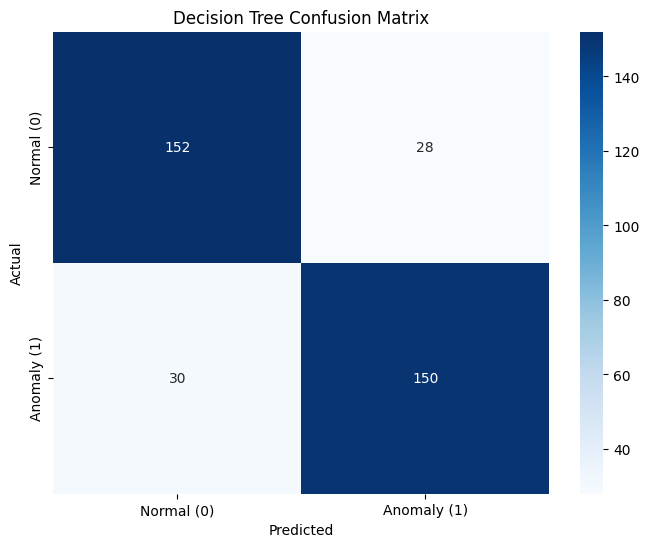


Accuracy: 0.8389


In [ ]:
# Import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
dec_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
print("Training the Decision Tree Classifier model...")
dec_tree_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_dt = dec_tree_model.predict(X_test)

print("\n======== Decision Tree Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy: {accuracy_dt:.4f}")

### 4.3. Random Forest Classifier

Training the RandomForestClassifier...
Training complete.

======== Random Forest Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92       180
         1.0       0.94      0.89      0.92       180

    accuracy                           0.92       360
   macro avg       0.92      0.92      0.92       360
weighted avg       0.92      0.92      0.92       360


Confusion Matrix:
[[170  10]
 [ 19 161]]


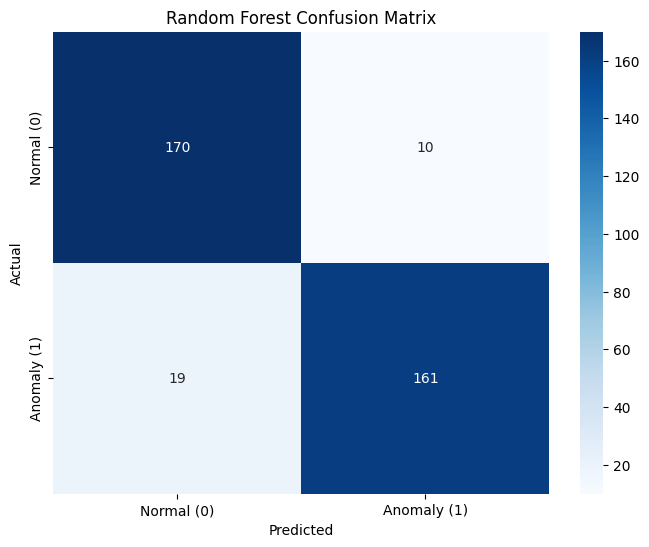


Accuracy: 0.9194


In [ ]:
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
# n_estimators is the number of trees in the forest
# random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training the RandomForestClassifier...")
rf_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("\n======== Random Forest Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy: {accuracy_rf:.4f}")

### 4.4. Support Vector Machine (SVM) Classifier

Training the Support Vector Machine model...
Training complete.

======== SVM Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.61      0.56      0.58       180
         1.0       0.59      0.64      0.61       180

    accuracy                           0.60       360
   macro avg       0.60      0.60      0.60       360
weighted avg       0.60      0.60      0.60       360


Confusion Matrix:
[[101  79]
 [ 65 115]]


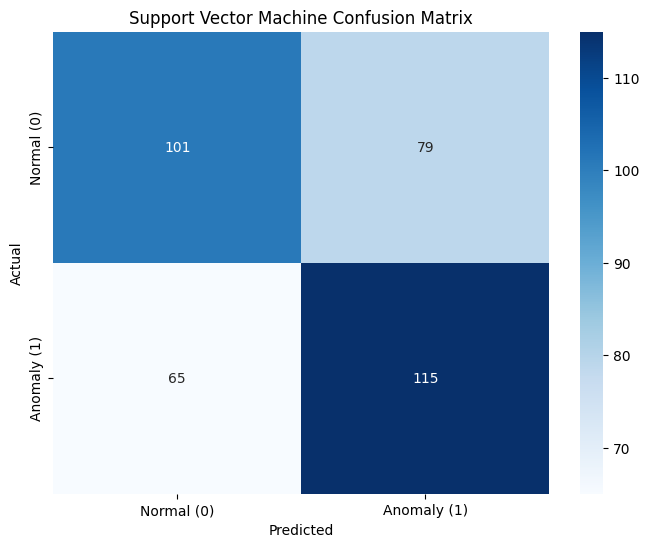


Accuracy: 0.6000


In [ ]:
# Import SVC (Support Vector Classifier)
from sklearn.svm import SVC

# Initialize the SVC model
# Using a linear kernel for simplicity and to compare with other linear models
# C is the regularization parameter. A smaller C promotes a wider margin.
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
print("Training the Support Vector Machine model...")
svm_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

print("\n======== SVM Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Support Vector Machine Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nAccuracy: {accuracy_svm:.4f}")

### 4.5. Hidden Markov Model (HMM) for Anomaly Detection

In [ ]:
# Install hmmlearn library
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.8 MB/s eta 0:00:00


Starting HMM parameter tuning for n_components...

================ Tuning HMM with n_components = 1 ================

Training the HMM model with 1 components on normal traffic...
HMM training complete.

======== HMM Evaluation (n_components = 1) ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.48      0.87      0.62       180
         1.0       0.31      0.06      0.10       180

    accuracy                           0.46       360
   macro avg       0.40      0.46      0.36       360
weighted avg       0.40      0.46      0.36       360


Confusion Matrix:
[[156  24]
 [169  11]]

Accuracy: 0.4639
================ Tuning HMM with n_components = 2 ================

Training the HMM model with 2 components on normal traffic...
HMM training complete.

======== HMM Evaluation (n_components = 2) ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.48      0.89      0.63    

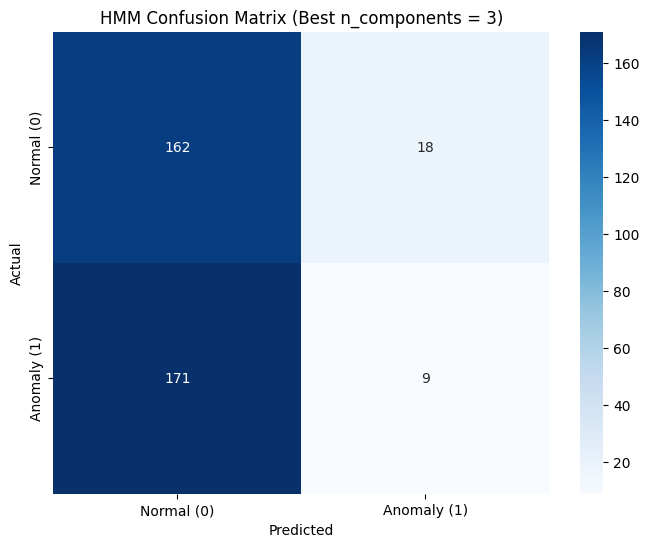


Final Best HMM Accuracy: 0.4750 with n_components = 3

Log-likelihood for normal test data (best model, full sequence): -460.0439
Log-likelihood for anomalous test data (best model, full sequence): -1640.4866


In [ ]:
from hmmlearn import hmm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for HMM: Train on normal traffic only
X_train_normal = X_train[y_train == 0]
X_test_normal = X_test[y_test == 0]
X_test_anomaly = X_test[y_test == 1]

# List of n_components to try for parameter tuning
# Refined range: previous runs showed best performance for n_components around 2-3.
# Higher values led to 'transmat_ have zero sum' warnings due to unobserved transitions
# which might indicate model complexity exceeding data density or suitability for HMM.
n_components_list = [1, 2, 3, 4, 5]
best_accuracy = -1
best_n_components = None
best_y_pred_hmm = None
best_cm_hmm = None

print("Starting HMM parameter tuning for n_components...\n")

for n_comp in n_components_list:
    print(f"================ Tuning HMM with n_components = {n_comp} ================\n")

    # Initialize a Gaussian HMM model
    hmm_model = hmm.GaussianHMM(n_components=n_comp, covariance_type="diag", n_iter=100, random_state=42)

    # Train the HMM model on normal training data
    print(f"Training the HMM model with {n_comp} components on normal traffic...")
    try:
        hmm_model.fit(X_train_normal)
        print("HMM training complete.")
    except Exception as e:
        print(f"Error training HMM with {n_comp} components: {e}")
        continue

    # Calculate log-likelihood for each individual sample in the training set (normal)
    # This loop can be slow for very large datasets, but for 720 samples, it should be fine.
    single_sample_log_likelihoods_train_normal = [hmm_model.score(X_train_normal[i:i+1]) for i in range(X_train_normal.shape[0])]

    # Determine a more robust threshold: e.g., 5th percentile of normal training scores
    # Samples with a log-likelihood below this threshold are considered anomalous.
    threshold_hmm_current = np.percentile(single_sample_log_likelihoods_train_normal, 10) # 5th percentile

    # Calculate log-likelihood for each individual sample in the test set
    single_sample_log_likelihoods_test = [hmm_model.score(X_test[i:i+1]) for i in range(X_test.shape[0])]

    # Predict anomalies: 1 for anomaly, 0 for normal
    y_pred_hmm_current = np.array([1 if score < threshold_hmm_current else 0 for score in single_sample_log_likelihoods_test])

    print(f"\n======== HMM Evaluation (n_components = {n_comp}) ========\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred_hmm_current))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm_hmm_current = confusion_matrix(y_test, y_pred_hmm_current)
    print(cm_hmm_current)

    # Accuracy Score
    accuracy_hmm_current = accuracy_score(y_test, y_pred_hmm_current)
    print(f"\nAccuracy: {accuracy_hmm_current:.4f}")

    # Store best model
    if accuracy_hmm_current > best_accuracy:
        best_accuracy = accuracy_hmm_current
        best_n_components = n_comp
        best_y_pred_hmm = y_pred_hmm_current
        best_cm_hmm = cm_hmm_current

print(f"\n================ Best HMM Model Found (n_components = {best_n_components}) ================\n")
y_pred_hmm = best_y_pred_hmm
accuracy_hmm = best_accuracy
cm_hmm = best_cm_hmm

# Visualize Confusion Matrix for the best model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hmm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'HMM Confusion Matrix (Best n_components = {best_n_components})')
plt.show()

print(f"\nFinal Best HMM Accuracy: {accuracy_hmm:.4f} with n_components = {best_n_components}")

# Calculate log-likelihoods for test data (normal and anomalous) - using the best model for general info
if best_n_components is not None:
    best_hmm_model = hmm.GaussianHMM(n_components=best_n_components, covariance_type="diag", n_iter=100, random_state=42)
    best_hmm_model.fit(X_train_normal) # Retrain the best model for consistency
    log_likelihood_test_normal = best_hmm_model.score(X_test_normal)
    log_likelihood_test_anomaly = best_hmm_model.score(X_test_anomaly)
    print(f"\nLog-likelihood for normal test data (best model, full sequence): {log_likelihood_test_normal:.4f}")
    print(f"Log-likelihood for anomalous test data (best model, full sequence): {log_likelihood_test_anomaly:.4f}")

### 4.6. Isolation Forest for Anomaly Detection

Training the Isolation Forest model...
Training complete.

======== Isolation Forest Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.45      0.78      0.58       180
         1.0       0.22      0.06      0.10       180

    accuracy                           0.42       360
   macro avg       0.34      0.42      0.34       360
weighted avg       0.34      0.42      0.34       360


Confusion Matrix:
[[141  39]
 [169  11]]


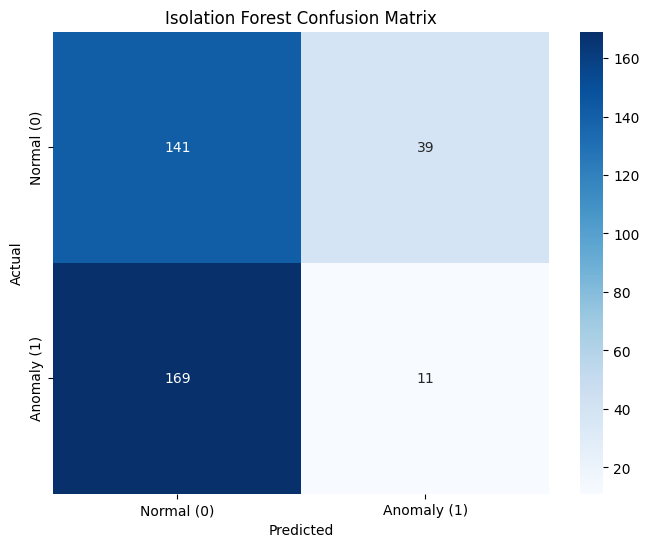


Accuracy: 0.4222


In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
# Contamination is the proportion of outliers in the data set.
# Setting it to 'auto' or a value like 0.1 (based on our 10% anomaly rate in original data) is common.
# Here, we'll assume 10% for consistency with the original dataset's imbalance.
iso_forest_model = IsolationForest(random_state=42, contamination=0.1, n_estimators=200, max_features=1.0, max_samples='auto')

# Train the model on the full training data (as Isolation Forest is unsupervised)
print("Training the Isolation Forest model...")
iso_forest_model.fit(X_train)
print("Training complete.")

# Predict anomaly scores for the test set
# Isolation Forest outputs a decision_function where lower values indicate more anomalous samples.
# It also has a 'predict' method which outputs -1 for outliers and 1 for inliers.
# We need to convert this to our 0 (normal), 1 (anomaly) format.

y_pred_iso = iso_forest_model.predict(X_test)
# Convert -1 (outlier) to 1 (anomaly) and 1 (inlier) to 0 (normal)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

print("\n======== Isolation Forest Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_iso))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_iso = confusion_matrix(y_test, y_pred_iso)
print(cm_iso)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_iso = accuracy_score(y_test, y_pred_iso)
print(f"\nAccuracy: {accuracy_iso:.4f}")

### 4.7. Autoencoders for Anomaly Detection

Training Autoencoder on normal data...
Autoencoder training complete.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

======== Autoencoder Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.96      0.66       180
         1.0       0.46      0.03      0.06       180

    accuracy                           0.50       360
   macro avg       0.48      0.50      0.36       360
weighted avg       0.48      0.50      0.36       360


Confusion Matrix:
[[173   7]
 [174   6]]


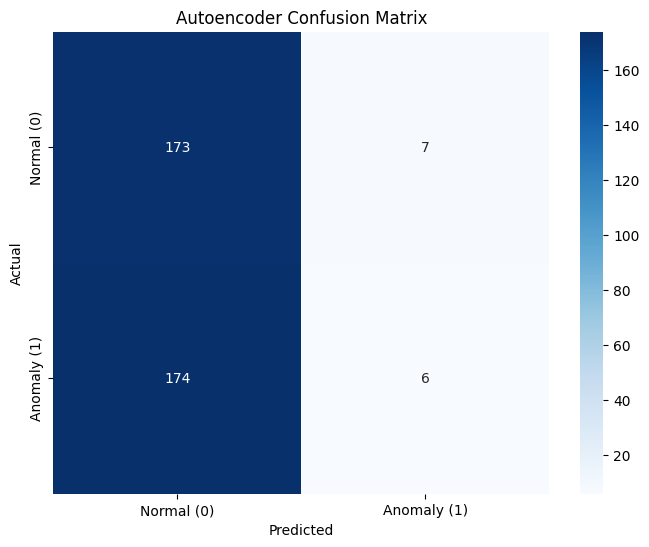


Accuracy: 0.4972


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the Autoencoder model
input_dim = X_train.shape[1]
encoding_dim = 5  # This is a hyperparameter to tune: dimensionality of the encoded representation

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="relu")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the autoencoder on normal data (or all data, depending on assumption of anomaly presence in training)
# For anomaly detection, autoencoders are typically trained on normal data to learn its features.
# Anomalies will have high reconstruction error.
print("Training Autoencoder on normal data...")
autoencoder.fit(X_train_normal, X_train_normal,
                epochs=50,
                batch_size=32,
                shuffle=True,
                validation_data=(X_test_normal, X_test_normal),
                verbose=0) # Set verbose to 1 to see training progress
print("Autoencoder training complete.")

# Predict reconstruction errors on the test set
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

# Determine a threshold for anomaly detection based on training reconstruction errors
train_reconstructions = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_reconstructions, 2), axis=1)

# Threshold can be set, e.g., as the 95th or 99th percentile of normal training errors
threshold_ae = np.percentile(train_mse, 95) # Anomalies will have reconstruction error above this

# Predict anomalies: 1 for anomaly, 0 for normal
y_pred_ae = np.array([1 if error > threshold_ae else 0 for error in mse])

print("\n======== Autoencoder Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_ae))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_ae = confusion_matrix(y_test, y_pred_ae)
print(cm_ae)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Autoencoder Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_ae = accuracy_score(y_test, y_pred_ae)
print(f"\nAccuracy: {accuracy_ae:.4f}")

### 4.9. Gaussian Mixture Model (GMM) for Anomaly Detection

Starting GMM parameter tuning for n_components...

================ Tuning GMM with n_components = 1 ================

Training the GMM model with 1 components on normal traffic...
Training complete.

======== GMM Evaluation (n_components = 1) ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.48      0.92      0.63       180
         1.0       0.18      0.02      0.03       180

    accuracy                           0.47       360
   macro avg       0.33      0.47      0.33       360
weighted avg       0.33      0.47      0.33       360


Confusion Matrix:
[[166  14]
 [177   3]]

Accuracy: 0.4694
================ Tuning GMM with n_components = 2 ================

Training the GMM model with 2 components on normal traffic...
Training complete.

======== GMM Evaluation (n_components = 2) ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.92      0.66       180
 

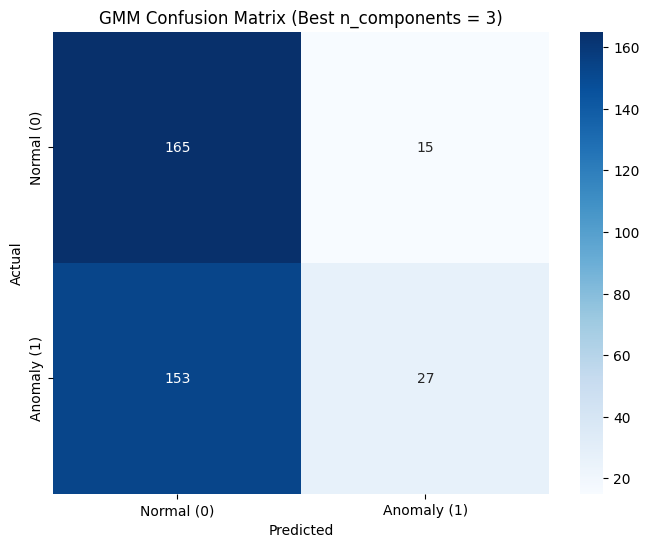


Final Best GMM Accuracy: 0.5333 with n_components = 3


In [ ]:
from sklearn.mixture import GaussianMixture

# List of n_components to try for parameter tuning
n_components_list = [1, 2, 3, 4, 5]
best_accuracy = -1
best_n_components = None
best_y_pred_gmm = None
best_cm_gmm = None

print("Starting GMM parameter tuning for n_components...\n")

for n_comp in n_components_list:
    print(f"================ Tuning GMM with n_components = {n_comp} ================\n")

    # Initialize GMM model
    # n_components: number of Gaussian components (clusters) in the mixture
    # We fit the GMM on normal training data, assuming anomalies do not conform to these Gaussian distributions.
    # A common approach is to treat samples with very low likelihood under the trained GMM as anomalies.
    gmm_model = GaussianMixture(n_components=n_comp, random_state=42, covariance_type='full') # n_components is a hyperparameter

    # Train the GMM model on normal training data
    print(f"Training the GMM model with {n_comp} components on normal traffic...")
    try:
        gmm_model.fit(X_train_normal)
        print("Training complete.")
    except Exception as e:
        print(f"Error training GMM with {n_comp} components: {e}")
        continue

    # Calculate log-likelihood for each sample in the test set
    # Low log-likelihood values indicate that the sample does not fit the normal distribution learned by the GMM.
    log_likelihoods_gmm_current = gmm_model.score_samples(X_test)

    # Determine a threshold for anomaly detection (e.g., 5th percentile of normal data's log-likelihoods)
    train_log_likelihoods_gmm_current = gmm_model.score_samples(X_train_normal)
    threshold_gmm_current = np.percentile(train_log_likelihoods_gmm_current, 5) # 5th percentile

    # Predict anomalies: 1 for anomaly, 0 for normal
    y_pred_gmm_current = np.array([1 if score < threshold_gmm_current else 0 for score in log_likelihoods_gmm_current])

    print(f"\n======== GMM Evaluation (n_components = {n_comp}) ========\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred_gmm_current))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm_gmm_current = confusion_matrix(y_test, y_pred_gmm_current)
    print(cm_gmm_current)

    # Accuracy Score
    accuracy_gmm_current = accuracy_score(y_test, y_pred_gmm_current)
    print(f"\nAccuracy: {accuracy_gmm_current:.4f}")

    # Store best model
    if accuracy_gmm_current > best_accuracy:
        best_accuracy = accuracy_gmm_current
        best_n_components = n_comp
        best_y_pred_gmm = y_pred_gmm_current
        best_cm_gmm = cm_gmm_current

print(f"\n================ Best GMM Model Found (n_components = {best_n_components}) ================\n")
y_pred_gmm = best_y_pred_gmm
accuracy_gmm = best_accuracy
cm_gmm = best_cm_gmm

# Visualize Confusion Matrix for the best model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'GMM Confusion Matrix (Best n_components = {best_n_components})')
plt.show()

print(f"\nFinal Best GMM Accuracy: {accuracy_gmm:.4f} with n_components = {best_n_components}")

### 4.10. Elliptical Envelope for Anomaly Detection

Training the Elliptic Envelope model on normal traffic...
Training complete.

======== Elliptic Envelope Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.48      0.92      0.63       180
         1.0       0.18      0.02      0.03       180

    accuracy                           0.47       360
   macro avg       0.33      0.47      0.33       360
weighted avg       0.33      0.47      0.33       360


Confusion Matrix:
[[166  14]
 [177   3]]


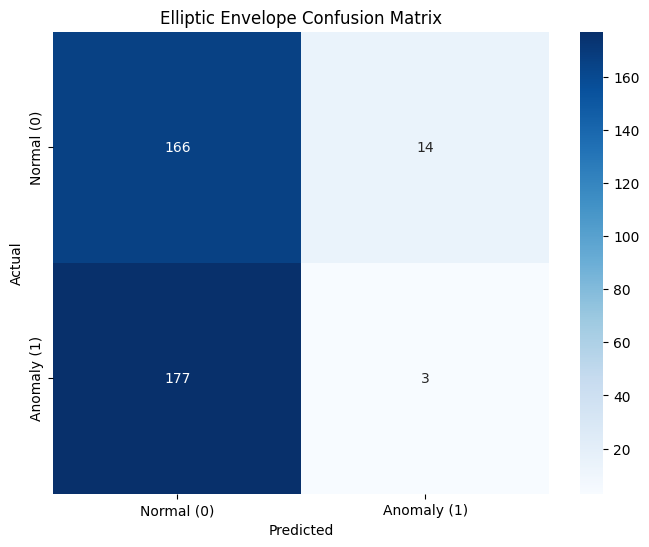


Accuracy: 0.4694


In [ ]:
from sklearn.covariance import EllipticEnvelope

# Initialize Elliptic Envelope model
# contamination is the proportion of outliers in the data set
# We fit the Elliptic Envelope on normal training data, to estimate the parameters of a Gaussian distribution
# The model then identifies samples that lie outside a learned elliptic envelope as anomalies.

elliptic_envelope_model = EllipticEnvelope(random_state=42, contamination=0.05) # contamination is a hyperparameter

# Train the model on normal training data
print("Training the Elliptic Envelope model on normal traffic...")
elliptic_envelope_model.fit(X_train_normal)
print("Training complete.")

# Predict anomaly labels for the test set
# EllipticEnvelope outputs 1 for inliers and -1 for outliers.
# We need to convert this to our 0 (normal), 1 (anomaly) format.
y_pred_ee = elliptic_envelope_model.predict(X_test)
# Convert -1 (outlier) to 1 (anomaly) and 1 (inlier) to 0 (normal)
y_pred_ee = np.where(y_pred_ee == -1, 1, 0)

print("\n======== Elliptic Envelope Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_ee))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_ee = confusion_matrix(y_test, y_pred_ee)
print(cm_ee)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ee, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Elliptic Envelope Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_ee = accuracy_score(y_test, y_pred_ee)
print(f"\nAccuracy: {accuracy_ee:.4f}")

### 5. Final Model Performance Summary


======== Detailed Model Performance Summary ========

Detailed Performance Summary (Sorted by F1-Score for Anomaly Class):

                    Model  Accuracy  Precision (Anomaly)  Recall (Anomaly)  \
0           Random Forest    0.9194               0.9415            0.8944   
1           Decision Tree    0.8389               0.8427            0.8333   
2  Support Vector Machine    0.6000               0.5928            0.6389   
3     Logistic Regression    0.6222               0.6310            0.5889   
4  Gaussian Mixture Model    0.5333               0.6429            0.1500   
5        Isolation Forest    0.4222               0.2200            0.0611   
6     Hidden Markov Model    0.4750               0.3333            0.0500   
7             Autoencoder    0.4972               0.4615            0.0333   
8       Elliptic Envelope    0.4694               0.1765            0.0167   

   F1-Score (Anomaly)  
0              0.9174  
1              0.8380  
2              0.6150 

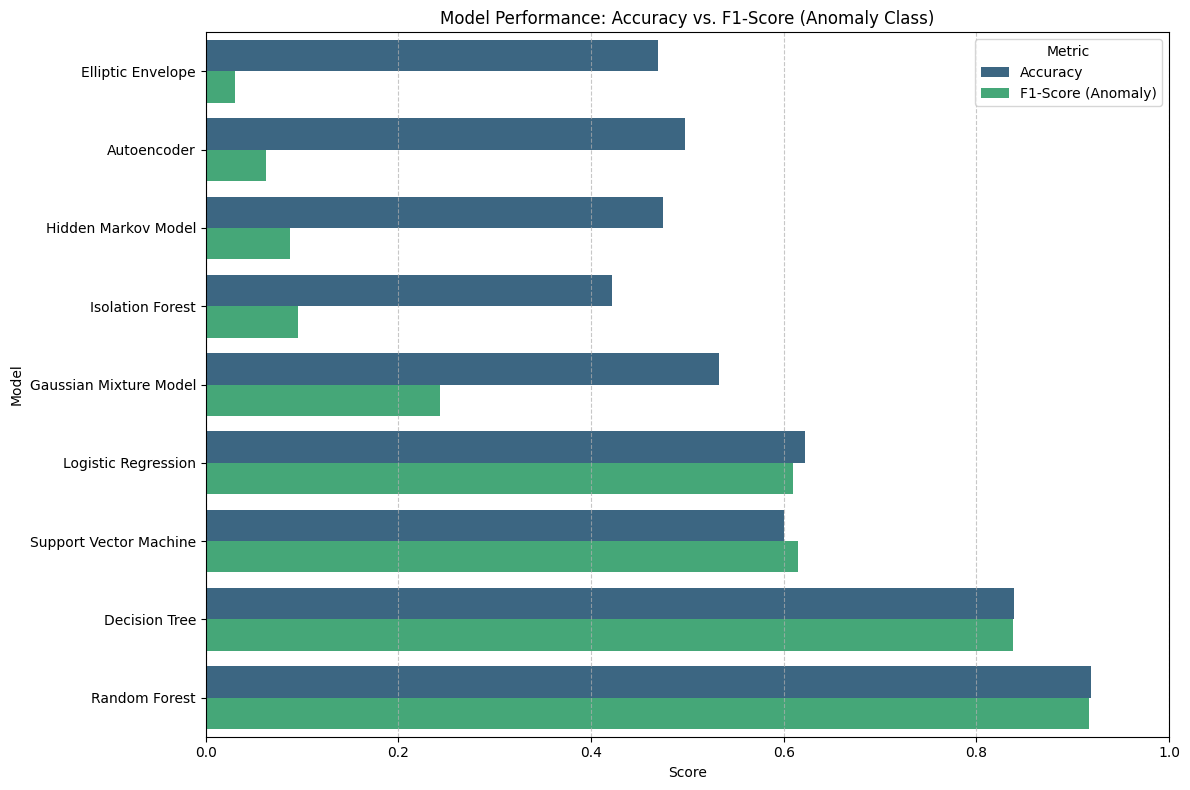

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n======== Detailed Model Performance Summary ========\n")

model_names = [
    'Logistic Regression', 'Decision Tree', 'Random Forest',
    'Support Vector Machine', 'Hidden Markov Model',
    'Isolation Forest', 'Autoencoder',
    'Gaussian Mixture Model', 'Elliptic Envelope'
]

y_preds = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Support Vector Machine': y_pred_svm,
    'Hidden Markov Model': y_pred_hmm,
    'Isolation Forest': y_pred_iso,
    'Autoencoder': y_pred_ae,
    'Gaussian Mixture Model': y_pred_gmm,
    'Elliptic Envelope': y_pred_ee
}

performance_summary_data = []

for name in model_names:
    y_pred = y_preds[name]

    # Ensure y_pred and y_test are numpy arrays for consistent metric calculation
    y_pred_arr = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    y_test_arr = y_test.values if isinstance(y_test, pd.Series) else y_test

    acc = accuracy_score(y_test_arr, y_pred_arr)

    # Metrics for the Anomaly class (label 1)
    prec_anomaly = precision_score(y_test_arr, y_pred_arr, pos_label=1, zero_division=0)
    rec_anomaly = recall_score(y_test_arr, y_pred_arr, pos_label=1, zero_division=0)
    f1_anomaly = f1_score(y_test_arr, y_pred_arr, pos_label=1, zero_division=0)

    performance_summary_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Anomaly)': prec_anomaly,
        'Recall (Anomaly)': rec_anomaly,
        'F1-Score (Anomaly)': f1_anomaly
    })

performance_df_detailed = pd.DataFrame(performance_summary_data)

# Sort by F1-Score for Anomaly Class, as it's often most crucial for imbalanced anomaly detection
performance_df_detailed = performance_df_detailed.sort_values(by='F1-Score (Anomaly)', ascending=False).reset_index(drop=True)

print("Detailed Performance Summary (Sorted by F1-Score for Anomaly Class):\n")
print(performance_df_detailed.round(4))

# Reshape the DataFrame for combined plotting of Accuracy and F1-Score
# Select only 'Model', 'Accuracy', and 'F1-Score (Anomaly)' for the plot
performance_for_plot = performance_df_detailed[['Model', 'Accuracy', 'F1-Score (Anomaly)']]

# Melt the DataFrame to have 'Metric' and 'Value' columns
performance_melted = performance_for_plot.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Sort by Accuracy for consistency in the plot order
# This sorts the models within each metric group
# For consistent model ordering across different metrics if needed for visualization clarity:
# You might want to sort the models based on one primary metric once and apply that order.
# Let's sort by F1-Score (Anomaly) for the model order on the y-axis, similar to the table.
model_order = performance_df_detailed.sort_values(by='F1-Score (Anomaly)', ascending=True)['Model'].tolist()

plt.figure(figsize=(12, 8))
sns.barplot(x='Value', y='Model', hue='Metric', data=performance_melted, palette='viridis', order=model_order)
plt.title('Model Performance: Accuracy vs. F1-Score (Anomaly Class)')
plt.xlabel('Score')
plt.ylabel('Model')
plt.xlim(0, 1) # Set x-axis limit from 0 to 1 for scores
plt.legend(title='Metric')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Training the XGBoost Classifier...
Training complete.

======== XGBoost Evaluation ========

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.96      0.93       180
         1.0       0.95      0.91      0.93       180

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360


Confusion Matrix:
[[172   8]
 [ 17 163]]


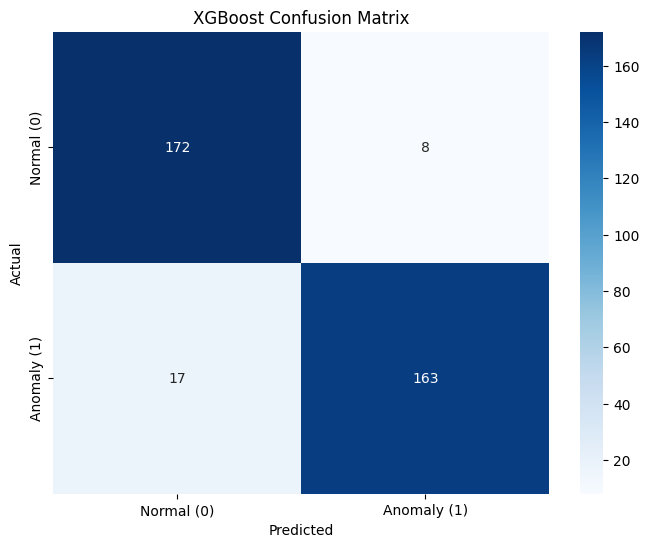


Accuracy: 0.9306


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Train the model
print("Training the XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

print("\n======== XGBoost Evaluation ========\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

# Accuracy Score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy: {accuracy_xgb:.4f}")